# Lesson 143 · RelGNN reproduction: defend the evidence

Student lab · PROVIDED / TODO / CHECK / EXIT. Tier B: full released relational task. Three live functions guard compatibility, checkpoint selection and verdict. Default CPU execution is distinct from the explicit GPU reproduction gate.

<!-- course-portable:start -->
### Follow the computation

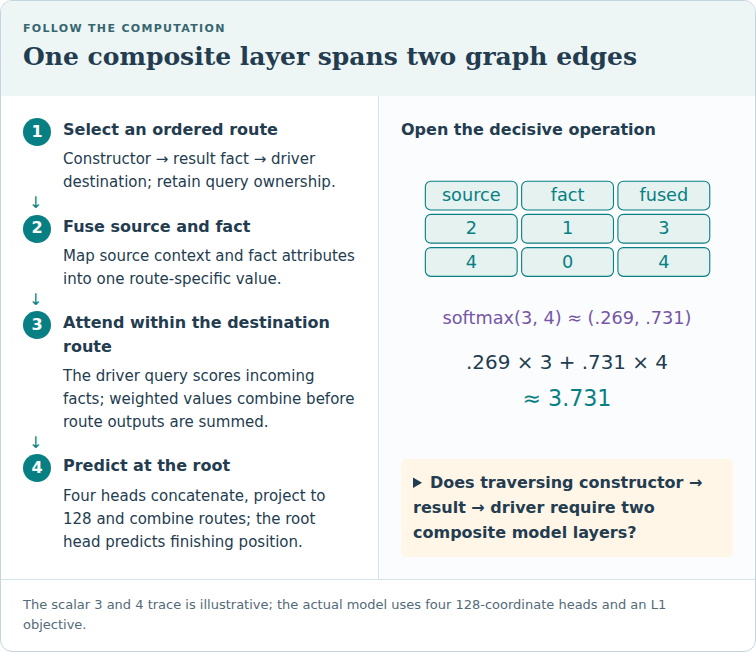

The scalar 3 and 4 trace is illustrative; the actual model uses four 128-coordinate heads and an L1 objective.

**Trace question:** Does traversing constructor → result → driver require two composite model layers?

**Trace answer:** No. One composite layer uses that two-edge route. Graph-hop distance and model-layer count differ.
<!-- course-portable:end -->

In [ ]:
# @colab-bootstrap — default is a portable CPU mechanism and evidence audit.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','sentence-transformers==3.3.1'])
from pathlib import Path
import base64,hashlib,io,json,zlib
import pandas as pd
from IPython.display import display
RUN_FULL_REPRODUCTION=False
FULL_SEEDS=list(range(5));PREPARED_ROOT=None


In [ ]:
"""RelGNN source-aligned architecture with explicit composite arithmetic.

MIT upstream cffdb8b54627e92c7dd112c1243dde739c90d35b; see sources/l141/LICENSE.
Selected variant: sum aggregation, no edge attributes, no simplified_MP.
PyG owns parameter containers; the load-bearing forward arithmetic is visible below.
"""
# %% Imports and live learner operators
import math
from collections import defaultdict
from typing import Any, Dict, List, Optional
import numpy as np
import torch
import torch_frame
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import LayerNorm, PositionalEncoding, MLP
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.conv import TransformerConv, SAGEConv
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.data import HeteroData
from torch_geometric.nn.module_dict import ModuleDict as RouteModuleDict


In [ ]:
# PROVIDED: author evidence and pinned original sources, not student results.
PACKET=base64.b64decode('...')
assert hashlib.sha256(PACKET).hexdigest()=='216a57dba5a0d10bccfd4088137768405fd5f1e3663671570d13236c9c849df5'
DATA=np.load(io.BytesIO(PACKET))
SOURCES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_ROOT=Path('sources/l141');SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,text in SOURCES.items():(SOURCE_ROOT/name).write_text(text)
AUTHOR_SUMMARY={'status': 'COMPLETE', 'replay': {'test': {'mae': 3.7373809045239494, 'max_original_error': 0.0}, 'val': {'mae': 2.8366607611228725, 'max_original_error': 0.0}}, 'reconstruction': {'val': {'mean': 3.1300641224809547, 'sample_sd': 0.08864337468210114}, 'test': {'mean': 4.221853429509882, 'sample_sd': 0.17351165216913544, 'descriptive_closeness': 'OUTSIDE_TOLERANCE'}}, 'verified_predictions': 7554, 'paper_test_mae': 3.798, 'tolerance': 0.2, 'source_artifact_hashes': {'replay-compatible/result.json': 'f62876bab8e623fac15e16b7f8d2f716f1ca999ed31715b1ee1b74d42b044323', 'replay-compatible/predictions.npz': 'eb47248381d9b79866cd2706070242362ee9477fd10cfa747a84577770b99120', 'replay-compatible/sampled_trace.npz': '91c2c648fd5f31734aad9416147449fee904c67e101ad9083fcadef6266b3711', 'seed-0/result.json': 'd7f69da3d9f479a5ff84549ed1010205a551887b561147a3da9414a0ded0eb38', 'seed-0/predictions.npz': '7db42d7f3720cebc3ba65a1c0cad212b8d5f98e4b088e697e1d613ea0829a663', 'seed-0/sampled_trace.npz': '00a28db35b4022c42aab5528424814a0fdbd818c2ba6070b04414f3ffdd1ec3c', 'seed-1/result.json': 'c4c9c57920ed865dbbbda7e05bb0c183cecaed57f8645b9e3c7b886c57b89f47', 'seed-1/predictions.npz': 'bf5657966e85371d68ed5ed484dd77cbe2e32f651d38f3dea63f9c7b10922465', 'seed-1/sampled_trace.npz': '0e9f8ad2d3514805552880c05760d4f8bb432d4e19228dcdb5bc25549e7aa6f2', 'seed-2/result.json': '0a62c4de387bdbe65379123ab45ce50b5bd7d4191e850ae31f9fa8d52e54eb48', 'seed-2/predictions.npz': '52df1eedc526ffaf1abc06aa0fa6c967490e6a4ee6048bce5f360dfd56f05bbe', 'seed-2/sampled_trace.npz': '5592f50ac7785b2fcc8cd02dc8ea6f534e1fa8ab435cbf17318fb8e967f6142a', 'seed-3/result.json': '95fd09a8d140e66d51ee345a3eec9fc5852620d665ab419c74dfe05b526f0843', 'seed-3/predictions.npz': '1c3caf04b74c208754cd7d629902f58fd3dd9b7750a1a721672b15d3317e421e', 'seed-3/sampled_trace.npz': 'd85d5b03ffd3e580a72d20a3dc16ac92596bb83e9e64e585ac751ded96556d7a', 'seed-4/result.json': 'aea07250833683f1d3939ae5278fb0e0695102d8b14ab918794ef5652df8fd15', 'seed-4/predictions.npz': '8fe60ab9cad68d3c8470689549807d3d11fabaa4aa274de12c6a0ec8b339838d', 'seed-4/sampled_trace.npz': '5ec25d691c6b3458a0ace1142e042e742b35b422e4f0fad5442b29e681d41ae2'}, 'historical_training': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE', 'verdict': {'execution': 'COMPLETE', 'score': 'OUTSIDE_TOLERANCE', 'historical': 'NOT_ESTABLISHED'}}
AUTHOR_HISTORIES={'replay-compatible': [], 'seed-0': [{'epoch': 1, 'train_l1': 8.798398998794607, 'val_mae': 4.217469164428508, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.794065934604371, 'val_mae': 4.47652208204658, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.601686323565038, 'val_mae': 3.8330068018727887, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.516856864769848, 'val_mae': 3.7291011927521223, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.42029945273813, 'val_mae': 3.40571150196817, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.1510174095238765, 'val_mae': 3.4812346146277133, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.9330211677919795, 'val_mae': 3.204123206288319, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.817442886696833, 'val_mae': 3.819986096014559, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.855034476731095, 'val_mae': 3.7543717641390875, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.735961808479718, 'val_mae': 3.3505809487385516, 'queries': 7453, 'steps': 15}], 'seed-1': [{'epoch': 1, 'train_l1': 9.025725932856984, 'val_mae': 4.298567381523097, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.86762730345817, 'val_mae': 4.427809367310467, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.582875589072755, 'val_mae': 4.203900766850474, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.4923836698301365, 'val_mae': 3.660611348352834, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.344107253133806, 'val_mae': 3.4741302787102932, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.04602568235832, 'val_mae': 3.250109191823181, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.911242949266842, 'val_mae': 3.0249335662953922, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.95692215321758, 'val_mae': 3.945410137074585, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 5.099974826636332, 'val_mae': 3.4891527719312934, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.873312494188467, 'val_mae': 3.1135742212982276, 'queries': 7453, 'steps': 15}], 'seed-2': [{'epoch': 1, 'train_l1': 9.071972873677163, 'val_mae': 4.350697674748096, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.891748296393973, 'val_mae': 4.399470550853089, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.574237145059165, 'val_mae': 3.7822915392552687, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.4572606078584265, 'val_mae': 3.4984876311613706, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.183673904703355, 'val_mae': 3.2901952298227437, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 4.997857049533147, 'val_mae': 3.207916257599631, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.92508232112306, 'val_mae': 3.1749302894653444, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.8819815109260105, 'val_mae': 3.228886649540128, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.869684138341327, 'val_mae': 3.0918925761220932, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.7755517622083, 'val_mae': 3.130643248573971, 'queries': 7453, 'steps': 15}], 'seed-3': [{'epoch': 1, 'train_l1': 8.701686810041334, 'val_mae': 4.177191862235009, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.776204043583332, 'val_mae': 4.518286287235115, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.588679897273887, 'val_mae': 4.00868656423463, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.495240354740566, 'val_mae': 3.6697432843541495, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.289759611037375, 'val_mae': 3.379320567340634, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.079697133266487, 'val_mae': 3.153952662022654, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.943299946315152, 'val_mae': 3.1382061515558375, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.921406752349087, 'val_mae': 3.2878765781481585, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.868166248689285, 'val_mae': 3.3364591209268917, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.779833512579405, 'val_mae': 3.2145993414288294, 'queries': 7453, 'steps': 15}], 'seed-4': [{'epoch': 1, 'train_l1': 8.965068445075891, 'val_mae': 4.276606882231667, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.844740075551951, 'val_mae': 4.460691829928575, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.624360792015953, 'val_mae': 4.039417857142712, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.538784958743747, 'val_mae': 3.873396540675549, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.483990662630772, 'val_mae': 3.457498054147643, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.313895612815672, 'val_mae': 3.3085189792579546, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.105989784462687, 'val_mae': 3.279649871973969, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.977299496257308, 'val_mae': 3.2834122552024416, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 5.010764408960363, 'val_mae': 3.2354533062987754, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.870786541940018, 'val_mae': 3.2428099685775975, 'queries': 7453, 'steps': 15}]}
AUTHOR_COMPATIBILITY={'before': {'number': 'numerical', 'position': 'categorical', 'date': 'timestamp'}, 'after': {'number': 'numerical', 'position': 'numerical', 'date': 'timestamp'}, 'evidence': {'mean': {'table': [12.338314551690347, 11.389024987751103], 'checkpoint': [12.3383150100708, 11.38902473449707]}, 'std': {'table': [7.558554498438097, 6.392023836085146], 'checkpoint': [7.558555603027344, 6.392024993896484]}}, 'historical_stypes_cache': 'NOT_ESTABLISHED', 'unchanged_other_tables': True}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">Turn a runnable model into an auditable claim</p>
<p><strong>Reading route.</strong> Freeze the recipe → verify feature meaning → inspect the forward pass → select a checkpoint → reconcile all runs.</p>
<details><summary>Quick prerequisite reminder</summary><p>MAE is the average absolute prediction error; lower is better. L1 loss uses those absolute errors for training. A gradient tells the optimizer how a parameter affects loss. NaN means “not a number”; finite predictions can coexist with invalid gradients. A differential oracle is an independent implementation run on the same inputs to compare outputs.</p></details>
</aside>
<!-- sequence-review:end -->

**The win:** run a complete selected RelGNN experiment and defend exactly what its evidence establishes. Plan about 25 minutes for the guided lesson, then a separate coding and written-defense session. Full training is an explicit GPU lane.

[Lesson 141](https://avistian.github.io/relational/lessons/0141-composite-message-passing.html) exposed the atomic-route computation. [Lesson 142](https://avistian.github.io/relational/lessons/0142-many-to-many-edge-pathology.html) tested why mixing roles can matter and compared two architectures. Neither recovered the original training history. Now the unresolved question is operational: **what must match before a number becomes reproduction evidence?** This serves our mission of making relational-model claims that survive independent scrutiny.

Start from memory: why does a two-edge route fit inside one composite layer? Why is validation allowed to choose an epoch while test is not? Name an example where a close score hides a different experiment.





## 1 · Freeze the claim before running

The named target is **RelGNN, rel-f1/driver-position, Table 2, test MAE 3.798** in [Chen et al., ICML 2025, §5.2](https://arxiv.org/html/2502.06784v2#S5.SS2). The paper reports five-run averages. We select one complete task from its benchmark, not the whole paper and not a reduced query sample.

The [pinned release](https://github.com/snap-stanford/RelGNN/tree/cffdb8b54627e92c7dd112c1243dde739c90d35b) provides the architecture and checkpoint-evaluation entry point. It does not fully specify the historical training run. We therefore freeze a **reconstructed training recipe** and name the gaps. A successful replay of supplied weights cannot fill them.

| Frozen item | Selected protocol |
|---|---|
| Query population | All 7,453 training, 499 validation, 760 test rows |
| Label | Mean recorded finishing position in `(cutoff, cutoff + 60 days]` |
| Data | Checksum-pinned full F1 archive; fresh graph materialization |
| Model | One composite layer, 128 output channels, four heads of 128 channels |
| Sampling | Uniform temporal 128/64 neighbors, bidirectional subgraph, batch 512 |
| Training | Adam .005, unclipped L1 loss, ten complete epochs, seeds 0–4 |
| Selection | First minimum validation MAE; no test-based tuning |
| Scoring | Unique `(driver, cutoff)` alignment; train-target 2/98 percentile clipping |
| Comparison | Mean and sample SD; predeclared ±0.20 MAE descriptive tolerance |

Five seeds and the architecture follow the chosen evidence target; optimizer, schedule and other unresolved details are documented reconstruction choices, not recovered historical facts. The tolerance is a course reporting rule, not a statistical equivalence test.

<figure class="route-figure" tabindex="0">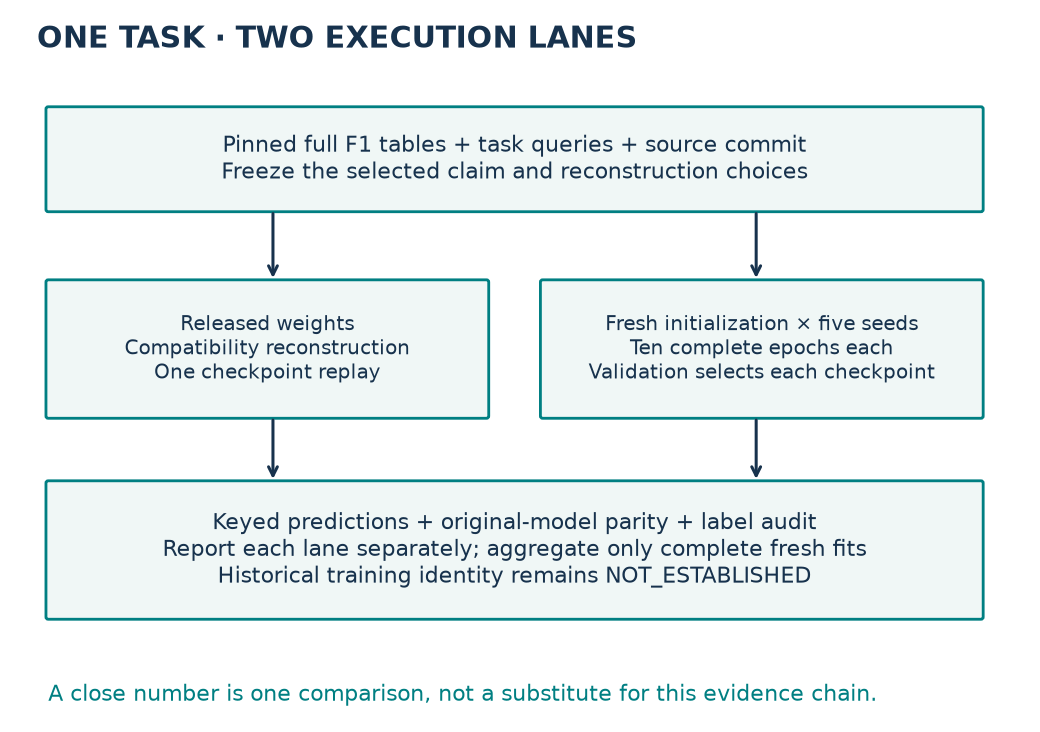<figcaption>Freeze the claim before observing scores. A complete task run and historical identity require different evidence. Scroll horizontally on a narrow screen.</figcaption></figure>

**Predict:** would five perfect checkpoint replays satisfy this five-fit training contract? No: repeated evaluation never supplies the missing training trajectories.



## 2 · Make feature meaning part of the checkpoint

A checkpoint tensor has a shape, but its columns also have meanings. Fresh inference assigns `qualifying.position` a categorical type. The released checkpoint expects two numerical columns. Loading it without intervention fails. Silently changing a type would conceal a different preprocessing path.

The compatibility reconstruction changes only this column to numerical. It then compares **ordered column means and population standard deviations** against the checkpoint's saved numerical normalization buffers. The candidate order is `[number, position]`; both buffers must agree within the declared tolerance. This is evidence for the proposed mapping, not proof of a unique mapping or recovery of the missing historical cache.

<figure class="route-figure" tabindex="0">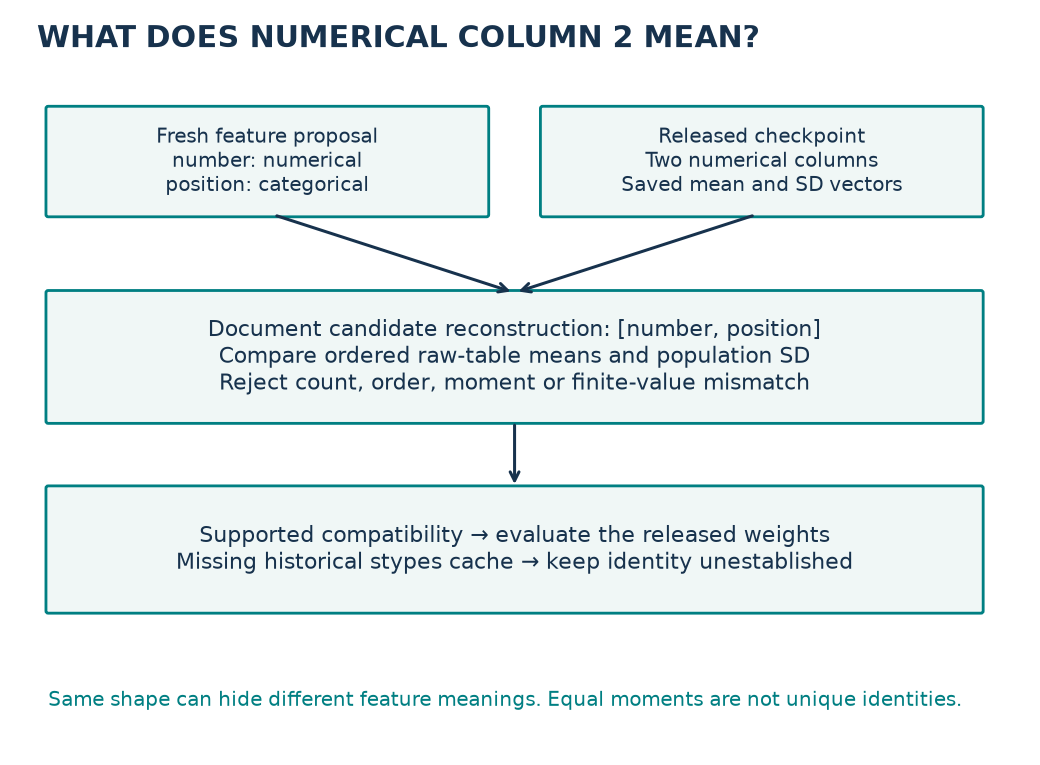<figcaption>Checkpoint shape is insufficient: compare ordered column moments. A supported reconstruction does not identify the historical cache. Scroll horizontally on a narrow screen.</figcaption></figure>

**TODO 1 — `verify_numeric_layout`:** check dimension, finite values, and ordered mean/std agreement. Reject an order swap even when every shape still matches. This function guards the actual compatibility materialization in the full notebook lane. Try predicting which check catches a wrong second column before running it.

The untouched freshly inferred graph goes to the training lane. The separately reconstructed graph goes to checkpoint replay. Comparing their scores does **not** isolate the feature-type effect: weights and training histories also differ.



In [ ]:
# TODO — this function is live in the implementation.
def verify_numeric_layout(columns, moments, checkpoint_mean, checkpoint_std):
    raise NotImplementedError("TODO: verify_numeric_layout")

In [ ]:
# CHECK — run unchanged.
import copy
def check_layout(fn):
    a={'number':(12.,3.),'position':(8.,2.)}
    assert fn(['number','position'],a,[12.,8.],[3.,2.]) is True
    for cols,mean,std in [(['position','number'],[12.,8.],[3.,2.]),(['number'],[12.,8.],[3.,2.]),(['number','position'],[12.,8.],[3.,9.]),(['number','position'],[12.,float('nan')],[3.,2.])]:
        try:fn(cols,a,mean,std)
        except ValueError:pass
        else:raise AssertionError('Accepted incompatible layout')
check_layout(verify_numeric_layout)
print("PASS verify_numeric_layout")

## 3 · Trace the computation you are reproducing

Follow one driver query through tables, sampling, row/time encoders, constructor→result→driver fusion, destination attention and the scalar head. The [source equations and architecture](https://arxiv.org/html/2502.06784v2#S4) explain why the intermediate fact row participates in the message rather than disappearing into a flattened join.

<figure class="route-figure" tabindex="0">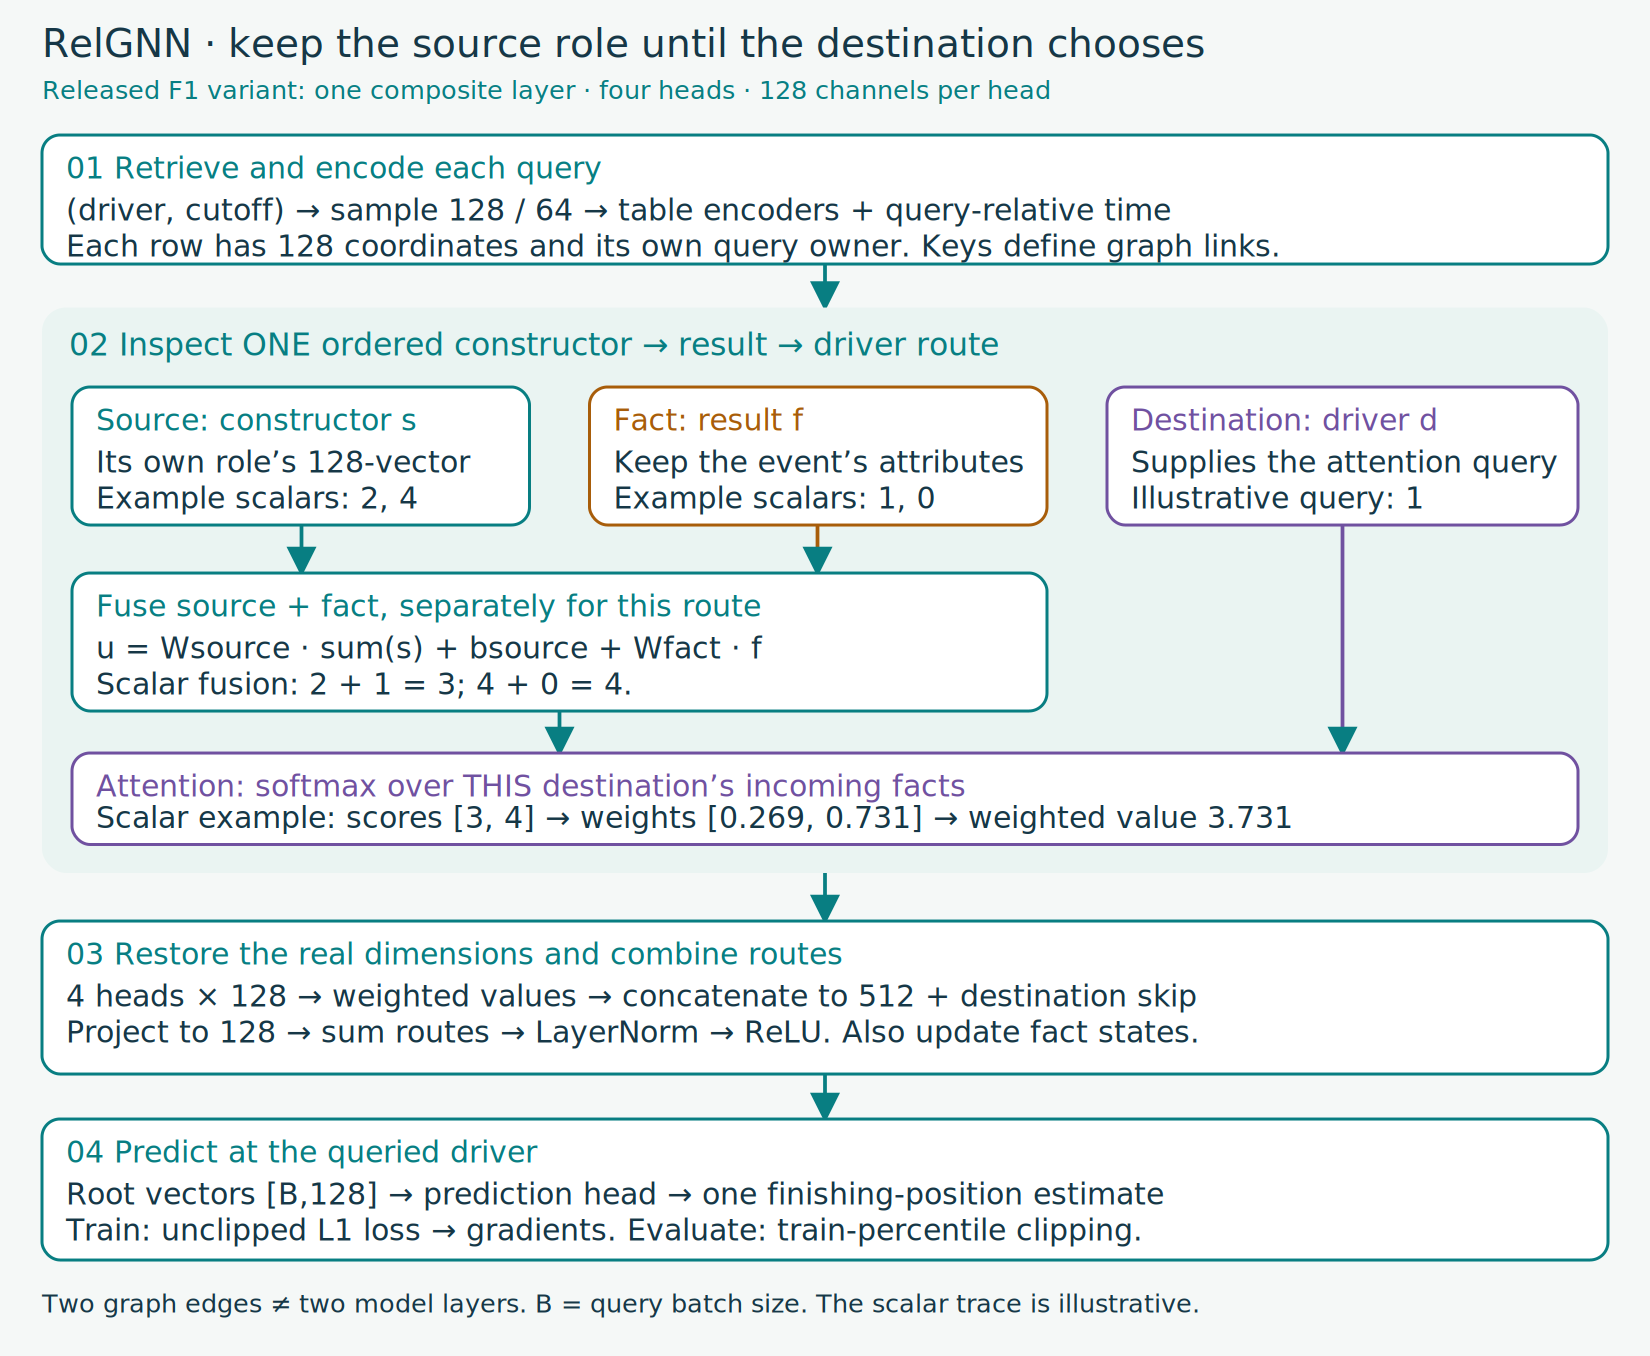<figcaption>Full selected RelGNN computation: owner-safe temporal sampling, row/time encoders, route fusion, destination attention and scalar driver prediction. Scroll horizontally on a narrow screen.</figcaption></figure>

The visible model below the notebook narrative implements the complete selected forward pass; the original source is a differential oracle. The trainer uses every training query each epoch and preserves owner-specific cutoffs in sampled batches. Source parity checks compare **unclipped** predictions on the same actual held-out batches, so clipping cannot hide model disagreement.

A source-matching implementation can still have a problem. The released numerical encoder produces nonfinite gradients in a missing-value path. We record their locations/counts and compare against the original implementation instead of repairing the model inside the reproduction. Finite predictions, a finite loss, and source parity do not establish healthy optimization. The evidence ledger distinguishes synthetic operator checks from the real first-batch gradient audit.

**Predict:** if only the gradient entries containing NaN agree with upstream, is the implementation correct? That evidence is insufficient: compare the finite entries and output tensors too, under matched dropout randomness.



In [ ]:
# PROVIDED — inspect this stage before running.
def get_atomic_routes(edge_type_list):
    
    src_to_tuples = defaultdict(list)
    for src, rel, dst in edge_type_list:
        if rel.startswith('f2p'):
            if src == dst:
                src = src + '--' + rel
            src_to_tuples[src].append((src, rel, dst))

    atomic_routes_list = []
    get_rev_edge = lambda edge: (edge[2], 'rev_' + edge[1], edge[0])
    for src, tuples in src_to_tuples.items():
        if '--' in src:
            src = src.split('--')[0]
        if len(tuples) == 1:
            _, rel, dst = tuples[0]
            edge = (src, rel, dst)
            atomic_routes_list.append(('dim-dim',) + edge)
            atomic_routes_list.append(('dim-dim',) + get_rev_edge(edge))
        else:
            for _, rel_q, dst_q in tuples:
                for _, rel_v, dst_v in tuples:
                    if rel_q != rel_v:
                        edge_q = (src, rel_q, dst_q)
                        edge_v = (src, rel_v, dst_v)                   
                        atomic_routes_list.append(('dim-fact-dim',) + edge_q + get_rev_edge(edge_v))

    return atomic_routes_list

def destination_softmax(scores, destination, num_destinations):
    """Normalize each head over incoming messages for the same destination."""
    index = destination[:, None].expand_as(scores)
    maxima = scores.new_full((num_destinations, scores.shape[1]), -torch.inf)
    maxima.scatter_reduce_(0, index, scores.detach(), reduce='amax', include_self=True)
    weights = (scores - maxima[destination]).exp()
    totals = scores.new_zeros((num_destinations, scores.shape[1]))
    totals.index_add_(0, destination, weights)
    return weights / (totals[destination] + 1e-16)

def keyed_mae(query_keys, targets, prediction_keys, predictions):
    """A repeated entity at another cutoff is a distinct forecast."""
    q = [tuple(k) for k in query_keys]; p = [tuple(k) for k in prediction_keys]
    y = np.asarray(targets, dtype=float); pred = np.asarray(predictions, dtype=float)
    if not q or len(set(q)) != len(q) or len(set(p)) != len(p) or set(q) != set(p):
        raise ValueError('Require equal unique query-key populations')
    if y.shape != (len(q),) or pred.shape != (len(p),) or not np.isfinite(y).all() or not np.isfinite(pred).all():
        raise ValueError('Require finite one-dimensional targets and predictions')
    lookup = dict(zip(p, pred))
    return float(np.mean(np.abs(y - np.array([lookup[k] for k in q]))))



In [ ]:
# PROVIDED — inspect this stage before running.
# %% Composite operator: role-specific fact representation then attention
class RelGNNConv(TransformerConv):
    def __init__(self, attn_type, in_channels, out_channels, heads, aggr,
                 simplified_MP=False, bias=True, **kwargs):
        super().__init__(in_channels, out_channels, heads, bias=bias, **kwargs)
        if aggr != 'sum' or simplified_MP:
            raise ValueError('This audited lesson implements the selected full sum variant')
        self.attn_type = attn_type
        if attn_type == 'dim-fact-dim':
            self.aggr_conv = SAGEConv(in_channels, out_channels, aggr=aggr)
        self.simplified_MP = simplified_MP
        self.final_proj = Linear(heads * out_channels, out_channels, bias=bias)
        self.final_proj.reset_parameters()

    def attend(self, source, destination, edges):
        # [nodes, heads, channels/head-output]; here each head outputs 128 channels.
        h, c = self.heads, self.out_channels
        q = self.lin_query(destination).view(-1, h, c)
        k = self.lin_key(source).view(-1, h, c)
        v = self.lin_value(source).view(-1, h, c)
        src, dst = edges
        scores = (q[dst] * k[src]).sum(-1) / math.sqrt(c)
        alpha = destination_softmax(scores, dst, len(destination))
        messages = v[src] * alpha[:, :, None]
        aggregate = messages.new_zeros((len(destination), h, c))
        aggregate.index_add_(0, dst, messages)
        # Source defaults: concatenate heads, add a destination skip, then project.
        joined = aggregate.reshape(len(destination), h*c) + self.lin_skip(destination)
        return self.final_proj(joined)

    def forward(self, x, edge_index, edge_attr=None, return_attention_weights=None):
        if edge_attr is not None or return_attention_weights is not None:
            raise ValueError('Selected experiment does not use edge attributes or attention return flags')
        if self.attn_type == 'dim-dim':
            return self.attend(x[0], x[1], edge_index)
        edge_attn, edge_aggr = edge_index
        source, fact, destination = x
        src, dst = edge_aggr
        gathered = source.new_zeros((len(fact), source.shape[1]))
        gathered.index_add_(0, dst, source[src])
        # SAGE sum + transformed fact root; unique to this ordered FK pair.
        intermediate = self.aggr_conv.lin_l(gathered) + self.aggr_conv.lin_r(fact)
        return self.attend(intermediate, destination, edge_attn), intermediate



In [ ]:
# PROVIDED — inspect this stage before running.
# %% Route dispatch and route-output sums
def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out
class RelGNN_HeteroConv(torch.nn.Module):

    def __init__(self, convs, aggr: Optional[str]='sum', simplified_MP: Optional[bool]=False):
        super().__init__()
        self.convs = RouteModuleDict(convs)
        self.aggr = aggr
        self.simplified_MP = simplified_MP

    def reset_parameters(self):
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(self, x_dict, edge_index_dict) -> Dict[NodeType, Tensor]:
        out_dict: Dict[str, List[Tensor]] = {}

        def update(out_dict, dst, out):
            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)
        for edge_type_info, conv in self.convs.items():
            attn_type = edge_type_info[0]
            if attn_type == 'dim-dim':
                src, rel, dst = edge_type_info[1:]
                x = (x_dict.get(src, None), x_dict.get(dst, None))
                edge_index = edge_index_dict[src, rel, dst]
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                update(out_dict, dst, out)
            elif attn_type == 'dim-fact-dim':
                edge_attn, edge_aggr = (edge_type_info[1:4], edge_type_info[4:])
                src_attn, _, dst = edge_attn
                src_aggr = edge_aggr[0]
                x = (x_dict[src_aggr], x_dict[src_attn], x_dict[dst])
                edge_index = (edge_index_dict[edge_attn], edge_index_dict[edge_aggr])
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                out_dst, out_src_attn = out
                update(out_dict, dst, out_dst)
                update(out_dict, src_attn, out_src_attn)
        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)
        if self.simplified_MP:
            for key, value in x_dict.items():
                if key not in out_dict:
                    out_dict[key] = value
        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'


In [ ]:
# PROVIDED — inspect this stage before running.
# %% Table encoders and query-relative time
class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict
class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


In [ ]:
# PROVIDED — inspect this stage before running.
# %% Composite stack and node normalization
class RelGNN(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "sum",
        num_model_layers: int = 2,
        num_heads: int = 1,
        simplified_MP=False,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            conv = RelGNN_HeteroConv(
                {
                    edge_type: RelGNNConv(edge_type[0], (channels, channels), channels, num_heads, aggr=aggr, simplified_MP=simplified_MP)
                    for edge_type in edge_types
                },
                aggr=aggr,
                simplified_MP=simplified_MP,
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict


In [ ]:
# PROVIDED — inspect this stage before running.
# %% Whole-model forward pass: table -> time -> routes -> head
class RelGNN_Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_model_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
        atomic_routes=None,
        num_heads=None,
        simplified_MP=False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = RelGNN(
            node_types=data.node_types,
            edge_types=atomic_routes,
            channels=channels,
            aggr=aggr,
            num_model_layers=num_model_layers,
            num_heads=num_heads,
            simplified_MP=simplified_MP,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])


In [ ]:
# PROVIDED/CHECK: full model fixture and original operator differential test
"""Synthetic whole-model forward/backward; no paper-result claim."""
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData

def neural_fixture(Model,route_builder):
    torch.set_num_threads(1);torch.manual_seed(141);data=HeteroData();stats={}
    for name,values in [('drivers',[1.,2.,3.,4.]),('results',[3.,5.,9.,10.]),('constructors',[2.,7.,11.,16.])]:
        frame=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
        data[name].tf=frame.tensor_frame;stats[name]=frame.col_stats;data[name].num_nodes=4
        data[name].batch=torch.tensor([0,1,0,1]);data[name].n_id=torch.arange(4)
    data['drivers'].seed_time=torch.tensor([864000,1728000]);data['results'].time=torch.tensor([777600,1555200,691200,1468800])
    for dst,fk in [('drivers','driverId'),('constructors','constructorId')]:
        edge=torch.tensor([[0,1,2,3],[0,1,0,1]])
        data['results','f2p_'+fk,dst].edge_index=edge;data[dst,'rev_f2p_'+fk,'results'].edge_index=edge.flip(0)
    model=Model(data,stats,1,128,1,'sum','batch_norm',atomic_routes=route_builder(data.edge_types),num_heads=4)
    model.train();pred=model(data,'drivers').view(-1);assert pred.shape==(2,)
    loss=torch.nn.functional.l1_loss(pred,torch.tensor([3.,5.]));loss.backward();report={}
    for name,part in [('encoder',model.encoder),('time',model.temporal_encoder),('gnn',model.gnn),('head',model.head)]:
        grads=[p.grad for p in part.parameters() if p.grad is not None]
        assert grads and all(torch.isfinite(g).all() for g in grads)
        norm=sum(float(g.square().sum()) for g in grads)**.5;assert norm>0
        report[name]=norm
    return dict(status='PASS',prediction=pred.detach().tolist(),loss=float(loss.detach()),gradient_norms=report,scope='finite synthetic fixture; real missing-value gradients audited separately')

"""Original source differential check, including outputs and all active gradients."""
import contextlib,sys,types
from pathlib import Path
import torch

@contextlib.contextmanager
def original_modules(source_root):
    names=['atomic_routes','relgnn_conv','relgnn_hetero_conv','relgnn_nn','relgnn_model']
    old={n:sys.modules.get(n) for n in names}
    try:
        for name in names:
            m=types.ModuleType(name);sys.modules[name]=m
            exec(compile((Path(source_root)/('examples__'+name+'.py')).read_text(),name,'exec'),m.__dict__)
        yield sys.modules['relgnn_model'].RelGNN_Model,sys.modules['relgnn_conv'].RelGNNConv
    finally:
        for n,m in old.items():
            if m is None:sys.modules.pop(n,None)
            else:sys.modules[n]=m

def check(source_root):
    torch.manual_seed(141);torch.set_num_threads(1)
    errors=[];gradients=0
    with original_modules(source_root) as (_,Original):
        for mode in ['dim-dim','dim-fact-dim']:
            for empty in [False,True]:
                a=RelGNNConv(mode,(4,4),4,2,aggr='sum').double()
                b=Original(mode,(4,4),4,2,aggr='sum').double();b.load_state_dict(a.state_dict())
                x=[torch.randn(n,4,dtype=torch.float64,requires_grad=True) for n in ([3,2] if mode=='dim-dim' else [3,4,2])]
                y=[v.detach().clone().requires_grad_() for v in x]
                e=torch.tensor([[0,1,2],[0,0,1]]) if not empty else torch.empty((2,0),dtype=torch.long)
                edges=e if mode=='dim-dim' else (e,torch.tensor([[0,1,2],[0,1,2]]))
                oa=a(tuple(x),edges);ob=b(tuple(y),edges)
                aa=(oa,) if mode=='dim-dim' else oa;bb=(ob,) if mode=='dim-dim' else ob
                for u,v in zip(aa,bb):
                    torch.testing.assert_close(u,v,atol=1e-12,rtol=1e-12);errors.append(float((u-v).abs().max().detach()))
                sum(u.square().sum() for u in aa).backward();sum(u.square().sum() for u in bb).backward()
                for (ka,pa),(kb,pb) in zip(a.named_parameters(),b.named_parameters()):
                    assert ka==kb
                    if pa.grad is not None:
                        torch.testing.assert_close(pa.grad,pb.grad,atol=1e-11,rtol=1e-11);gradients+=1
                for u,v in zip(x,y):torch.testing.assert_close(u.grad,v.grad,atol=1e-11,rtol=1e-11)
    return dict(status='PASS',cases=4,parameter_gradient_tensors=gradients,max_output_error=max(errors),dtype='float64',scope='operator outputs/input and parameter gradients; empty attention edges included')

fixture_report=neural_fixture(RelGNN_Model,get_atomic_routes)
parity_report=check(SOURCE_ROOT)
print(fixture_report);print(parity_report)

## 4 · Select without looking at test

During training, validation chooses a checkpoint. When two epochs share the minimum validation MAE, choose the first. A later tied checkpoint has no stronger selection evidence. Test is evaluated only after the choice; we do not shorten schedules or discard seeds because their test scores are worse.

**TODO 2 — `first_validation_min`:** accept a contiguous finite epoch history and return the first minimum. Ignore any supplied test metric. This function controls checkpoint saving in the visible full trainer, not just a standalone quiz.

Baseline validation [4,3,3]: first minimum selects epoch2.

The selection-time validation score and the final validation score can differ: temporal neighbor sampling is stochastic and final scoring draws another sample. Save both values. Seed variation also does not provide query-independent uncertainty; the same drivers occur at multiple dates.

The F1 test population has already been inspected in preceding lessons. New weights give fresh training evidence on this fixed population, not a newly untouched confirmatory dataset.



In [ ]:
# TODO — this function is live in the implementation.
def first_validation_min(history):
    raise NotImplementedError("TODO: first_validation_min")

In [ ]:
# CHECK — run unchanged.
import copy
def check_selection(fn):
    assert fn([{'epoch':1,'val_mae':4.},{'epoch':2,'val_mae':3.},{'epoch':3,'val_mae':3.}])==2
    assert fn([{'epoch':1,'val_mae':3.,'test_mae':9.},{'epoch':2,'val_mae':4.,'test_mae':1.}])==1
    for h in [[],[{'epoch':1,'val_mae':float('nan')}],[{'epoch':2,'val_mae':2.}]]:
        try:fn(h)
        except ValueError:pass
        else:raise AssertionError('Accepted invalid history')
check_selection(first_validation_min)
print("PASS first_validation_min")

## 5 · Reconcile all evidence before averaging

First verify full query keys against the task archive. Independently reconstruct labels from raw result rows, using the exact open-left, closed-right 60-day interval. Future participation determines which drivers have label rows; this benchmark is not a prospective prediction for every driver.

Then score each prediction file, check full schedules and chosen epochs, and verify five distinct fresh run IDs. Only after these checks may the five training metrics be aggregated. Keep the released-checkpoint metric on a separate row.

| Evidence lane | Validation MAE | Test MAE | What was executed |
|---|---:|---:|---|
| Published Table 2 | — | 3.798 | Reported five-seed mean |
| Checkpoint-compatible replay | 2.836661 | 3.737381 | One released set of weights; reconstructed qualifying types |
| Fresh reconstruction, five seeds | 3.130064 ± 0.088643 | 4.221853 ± 0.173512 | Ten full epochs per seed; sample SD |

All **7,554 held-out predictions** independently aligned and rescored. Fresh score comparison: **OUTSIDE_TOLERANCE**. Historical training: **NOT_ESTABLISHED**. Whole paper: **NOT_RUN**.

Independent raw-table reconstruction checked **8,712 labels**. The separate real first-batch source audit matched **640 nonfinite gradient entries** and a maximum finite-entry difference of **1.2e-07**. These gradient counts describe that diagnostic batch, not every seed or batch.

<figure class="route-figure" tabindex="0">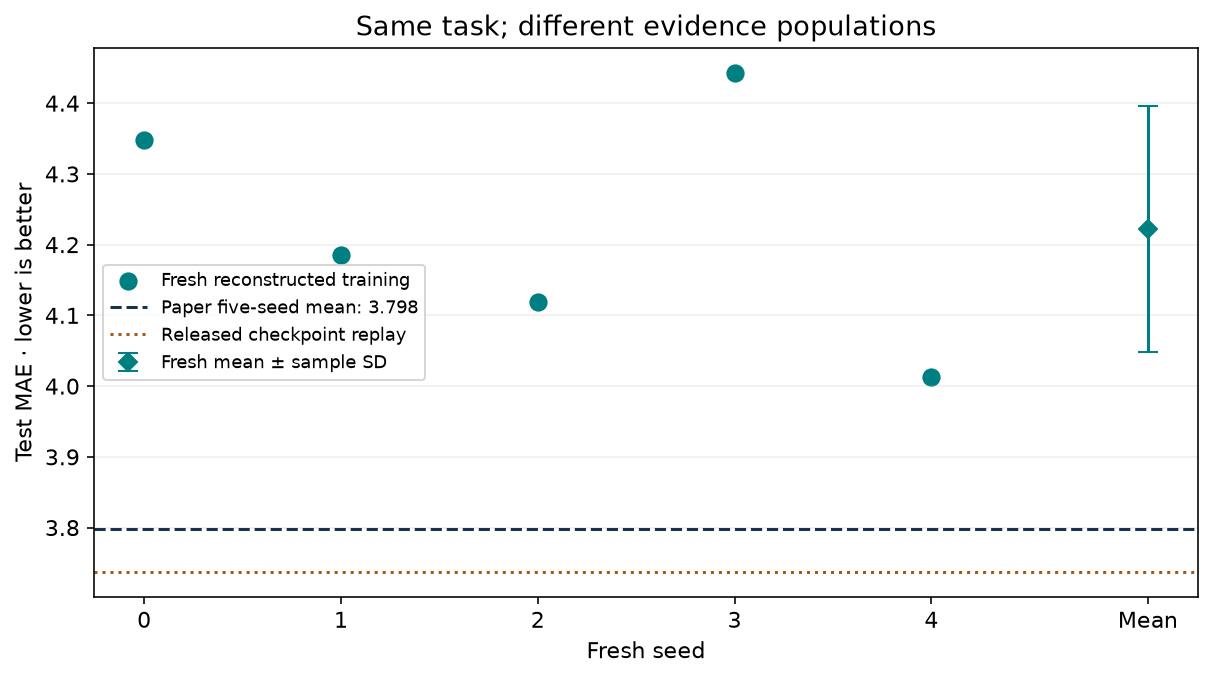<figcaption>Measured five-seed test scores and sample SD, separate from checkpoint replay and the published mean. Scroll horizontally on a narrow screen.</figcaption></figure>

**TODO 3 — `evidence_verdict`:** require one complete reconstructed ten-epoch fit for each seed 0–4. A missing seed, duplicate seed, replay substituted for training, nonfinite metric, or shortened run makes execution incomplete. On complete evidence, apply the frozen descriptive tolerance. Historical identity remains `NOT_ESTABLISHED` even when the mean is close.

Baseline five complete fresh fits, illustrative mean3.90: COMPLETE, CLOSE; historical identity NOT_ESTABLISHED.

The helper consumes validated run records; it cannot itself authenticate archives or reconstruct labels. The surrounding audit establishes those prerequisites. This division matters: passing a convenient summary into a function is not an evidence audit.



In [ ]:
# TODO — this function is live in the implementation.
def evidence_verdict(runs):
    raise NotImplementedError("TODO: evidence_verdict")

In [ ]:
# CHECK — run unchanged.
import copy
def check_verdict(fn):
    runs=[dict(seed=i,kind='RECONSTRUCTED_TRAINING',epochs=10,complete=True,test_mae=3.798) for i in range(5)]
    r=fn(runs);assert r['execution']=='COMPLETE' and r['score']=='CLOSE' and r['historical']=='NOT_ESTABLISHED'
    assert fn(runs[::-1])==r
    assert fn(runs[:-1])['execution']=='INCOMPLETE'
    for field,value in [('kind','CHECKPOINT_COMPATIBILITY_REPLAY'),('epochs',9),('complete',False),('test_mae',float('nan')),('seed',1)]:
        bad=copy.deepcopy(runs);bad[0][field]=value
        assert fn(bad)['execution']=='INCOMPLETE',(field,value)
    assert fn([dict(x,test_mae=3.998) for x in runs])['score']=='CLOSE'
    assert fn([dict(x,test_mae=4.267) for x in runs])['score']=='OUTSIDE_TOLERANCE'
check_verdict(evidence_verdict)
print("PASS evidence_verdict")

## 6 · Execute, then write the verdict

The [student notebook](https://avistian.github.io/relational/labs/0143-relgnn-reproduction.ipynb) contains three live TODOs, immediate checks, visible model/preprocessing/trainer code, embedded figures and hash-checked author evidence. The [executed solution](https://avistian.github.io/relational/labs/html/0143-relgnn-reproduction.html) demonstrates reference execution. The default CPU lane runs model fixtures and independently re-scores the author's predictions. It does not train the full task.

Set `RUN_FULL_REPRODUCTION=True` only in the documented pinned GPU environment to materialize the full graph, replay the compatible checkpoint and train all five fresh seeds. Its separate validation run uses seed100 plus replay, excluded from the five primary means. The [protocol and commands](https://avistian.github.io/relational/labs/l143-reproduction.md), [verification report](https://avistian.github.io/relational/labs/_verify_l143_results.json), and [reference](https://avistian.github.io/relational/reference/relgnn-reproduction.html) record what actually ran. Live Colab and deployment remain `NOT_CHECKED`.

The aggregate budget is **US$10**, including preparation, all attempts, notebook validation and overhead. Each cloud call reserves its maximum worker allocation before dispatch; a pilot gates the remaining fits. A failed run stays in the cost ledger. An incomplete budget-limited run is reported honestly, never silently replaced with a smaller experiment. [Provider rates](https://modal.com/pricing).

**EXIT — write before checking:** give a five-sentence report identifying the paper target, the two execution lanes, the measured fresh mean/SD, the unresolved historical gap, and one limitation that survives a close score. Explain why changing the numerical encoder now would require a separately named extension. Learner status remains `PENDING_WRITTEN_DEFENSE` until you complete the work and defend it.

Primary reading: [RelGNN §4 and §5.2](https://arxiv.org/html/2502.06784v2), then inspect the [released evaluation entry point](https://github.com/snap-stanford/RelGNN/blob/cffdb8b54627e92c7dd112c1243dde739c90d35b/examples/relgnn_task_node.py). Ask the teaching agent to challenge your evidence verdict or walk through any unclear tensor operation.

Write your EXIT explanation before consulting the reference answer.


<!-- sequence-next:start -->
**Carry this forward.** After predicting one number per driver, move to ranking many sponsors per facility. Lesson 144 asks how the candidate’s representation can depend on the query. [Continue to Lesson 144](https://avistian.github.io/relational/lessons/0144-contextgnn.html).
<!-- sequence-next:end -->


In [ ]:
# CHECK: your function evaluates all real author prediction vectors.
rows=[];rng=np.random.default_rng(141)
for phase in ['replay-compatible']+[f'seed-{i}' for i in range(5)]:
    for split in ['val','test']:
        prefix=phase+'_'+split+'_';keys=list(zip(DATA[prefix+'entity'],DATA[prefix+'time']))
        order=rng.permutation(len(keys))
        score=keyed_mae(keys,DATA[prefix+'target'],[keys[i] for i in order],DATA[prefix+'pred'][order])
        expected=float(np.mean(np.abs(DATA[prefix+'target']-DATA[prefix+'pred'])))
        assert abs(score-expected)<1e-12
        rows.append(dict(lane=phase,split=split,mae=score,queries=len(keys)))
display(pd.DataFrame(rows))
for phase,history in AUTHOR_HISTORIES.items():
    if history:
        assert len(history)==10 and all(x['queries']==7453 for x in history)
        assert first_validation_min(history)==1+int(np.argmin([x['val_mae'] for x in history]))
records=[dict(seed=i,kind='RECONSTRUCTED_TRAINING',epochs=len(AUTHOR_HISTORIES[f'seed-{i}']),complete=True,test_mae=next(r['mae'] for r in rows if r['lane']==f'seed-{i}' and r['split']=='test')) for i in range(5)]
assert evidence_verdict(records)==AUTHOR_SUMMARY['verdict']
e=AUTHOR_COMPATIBILITY['evidence'];moments={c:(e['mean']['table'][i],e['std']['table'][i]) for i,c in enumerate(['number','position'])}
assert verify_numeric_layout(['number','position'],moments,e['mean']['checkpoint'],e['std']['checkpoint'])
assert sum(r['queries'] for r in rows)==AUTHOR_SUMMARY['verified_predictions']


## Post-EXIT: full-data reproduction code

The complete preprocessing and trainer are visible below. They preserve live learner functions. The original source is only the differential oracle. Fresh training uses the frozen course recipe, and the compatibility helper documents the released checkpoint type mismatch. The GPU gate is off by default. See the protocol for budget and pinned execution commands.

In [ ]:
# PROVIDED: released graph construction and query loader inputs
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )


class LinkTrainTableInput(NamedTuple):
    r"""Training table input for link prediction.

    - src_nodes is a Tensor of source node indices.
    - dst_nodes is PyTorch sparse tensor in csr format.
        dst_nodes[src_node_idx] gives a tensor of destination node
        indices for src_node_idx.
    - num_dst_nodes is the total number of destination nodes.
        (used to perform negative sampling).
    - src_time is a Tensor of time for src_nodes
    """

    src_nodes: Tuple[NodeType, Tensor]
    dst_nodes: Tuple[NodeType, Tensor]
    num_dst_nodes: int
    src_time: Optional[Tensor]


def get_link_train_table_input(
    table: Table,
    task: RecommendationTask,
) -> LinkTrainTableInput:
    r"""Get the training table input for link prediction."""

    src_node_idx: Tensor = torch.from_numpy(
        table.df[task.src_entity_col].astype(int).values
    )
    exploded = table.df[task.dst_entity_col].explode()
    coo_indices = torch.from_numpy(
        np.stack([exploded.index.values, exploded.values.astype(int)])
    )
    sparse_coo = torch.sparse_coo_tensor(
        coo_indices,
        torch.ones(coo_indices.size(1), dtype=bool),
        (len(src_node_idx), task.num_dst_nodes),
    )
    dst_node_indices = sparse_coo.to_sparse_csr()

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    return LinkTrainTableInput(
        src_nodes=(task.src_entity_table, src_node_idx),
        dst_nodes=(task.dst_entity_table, dst_node_indices),
        num_dst_nodes=task.num_dst_nodes,
        src_time=time,
    )


In [ ]:
# PROVIDED: frozen full-data trainer
"""Full released-checkpoint replay and explicitly reconstructed fresh training.

Reconstruction: five seeds, ten complete epochs, Adam .005, L1, first validation
minimum. These choices are frozen course choices; historical training is unreleased.
"""
import hashlib,json,time,copy
from pathlib import Path
import numpy as np
import torch
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_frame.config import TextEmbedderConfig
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal

ARCHIVES={'db.zip':'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482','tasks/driver-position.zip':'775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}
CHECKPOINT_REVISION='321e6f6e7af5d7546b637f147783fc28ab5d4a7a'

CONFIG=dict(num_model_layers=1,channels=128,aggr='sum',num_heads=4)



In [ ]:
# PROVIDED: frozen full-data trainer
def sha(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        while chunk:=f.read(8*1024*1024):h.update(chunk)
    return h.hexdigest()



In [ ]:
# PROVIDED: frozen full-data trainer
def materialize(root,source_root):
    """Fresh full test-cutoff database and released GloVe row materialization."""
    import urllib.request,zipfile,importlib.metadata as md
    from sentence_transformers import SentenceTransformer
    from huggingface_hub import hf_hub_download
    root=Path(root);root.mkdir(parents=True,exist_ok=False);seed_everything(42);torch.set_num_threads(1)
    for name,digest in ARCHIVES.items():
        target=root/'cache'/name;target.parent.mkdir(parents=True,exist_ok=True)
        urllib.request.urlretrieve('https://relbench.stanford.edu/download/rel-f1/'+name,target)
        assert sha(target)==digest
        with zipfile.ZipFile(target) as z:z.extractall(root/'unpacked')
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear();db=dataset.get_db()
    # Fail closed if installed preprocessing differs from the vendored release.
    import relbench.modeling.graph as graph,relbench.modeling.nn as nn,relbench.modeling.utils as utils
    source_checks={}
    for module,name in [(graph,'graph'),(nn,'nn'),(utils,'utils')]:
        expected=Path(source_root)/f'relbench__modeling__{name}.py'
        source_checks[name]=Path(module.__file__).read_bytes()==expected.read_bytes()
    assert all(source_checks.values()),source_checks
    types=get_stype_proposal(db)
    text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cpu')
    def embed(strings):return text.encode(strings,convert_to_tensor=True)
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
    # Independent FK reconstruction from table rows, including missing references.
    fk_edges=0
    for table_name,table in db.table_dict.items():
        for column,parent in table.fkey_col_to_pkey_table.items():
            df=db.table_dict[parent].df;pk=db.table_dict[parent].pkey_col
            lookup={int(v):i for i,v in enumerate(df[pk])}
            expected={(i,lookup[int(v)]) for i,v in enumerate(table.df[column]) if not __import__('pandas').isna(v)}
            actual=set(map(tuple,data[(table_name,'f2p_'+column,parent)].edge_index.numpy().T))
            assert actual==expected,(table_name,column);fk_edges+=len(actual)
    torch.save((data,stats),root/'graph.pt')
    checkpoint=hf_hub_download('tianlangchen/RelGNN','rel-f1_driver-position.pth',revision=CHECKPOINT_REVISION)
    import shutil;shutil.copyfile(checkpoint,root/'released.pth')
    info=dict(graph_sha256=sha(root/'graph.pt'),checkpoint_sha256=sha(root/'released.pth'),checkpoint_revision=CHECKPOINT_REVISION,
        preprocessing='FRESH full released snapshot; seed42; pinned GloVe',archives=ARCHIVES,source_checks=source_checks,
        rows={k:len(t) for k,t in db.table_dict.items()},fk_edges=fk_edges,edges=sum(e.shape[1] for e in data.edge_index_dict.values()),
        routes=[list(r) for r in get_atomic_routes(data.edge_types)],packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']})
    (root/'prepared.json').write_text(json.dumps(info,indent=2));return info



In [ ]:
# PROVIDED: frozen full-data trainer
def full_run(output,prepared_root,source_root,seed=0,replay=False):
    """All query rows are used. Test is opened only after validation selection."""
    start=time.perf_counter();torch.set_num_threads(1);seed_everything(42 if replay else seed)
    out=Path(output);out.mkdir(parents=True,exist_ok=False);root=Path(prepared_root)
    prepared=json.loads((root/'prepared.json').read_text());assert sha(root/'graph.pt')==prepared['graph_sha256']
    for name,digest in ARCHIVES.items():assert sha(root/'cache'/name)==digest
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked'/'driver-position');task.get_table.cache_clear()
    train=task.get_table('train');clip=np.percentile(train.df[task.target_col].to_numpy(),[2,98]).tolist()
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(data=data,col_stats_dict=stats,out_channels=1,norm='batch_norm',atomic_routes=get_atomic_routes(data.edge_types),**CONFIG)
    model=RelGNN_Model(**kwargs).to(device)
    # Initial lazy columns must be materialized before a new optimizer is created.
    def loader(split):
        table=task.get_table(split,mask_input_cols=False)
        input_table=table
        if split=='test':
            from relbench.base import Table
            input_table=Table(df=table.df.drop(columns=[task.target_col]),fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,pkey_col=table.pkey_col,time_col=table.time_col)
        inp=get_node_train_table_input(table=input_table,task=task)
        return NeighborLoader(data,num_neighbors=[128,64],time_attr='time',input_nodes=inp.nodes,input_time=inp.time,transform=inp.transform,subgraph_type='bidirectional',batch_size=512,temporal_strategy='uniform',shuffle=split=='train',num_workers=0),table
    # Replay construction order matches source: val loader, test loader, model initialization.
    # Constructors do not sample; seed reset below matches original parameter RNG consumption.
    val_loader,val_table=loader('val')
    train_loader,_=loader('train') if not replay else (None,None)
    audit=dict(query_occurrences=0,timestamped_node_occurrences=0,future_violations=0);trace={};grad_norm=None;nonfinite_gradients={}
    def audit_batch(batch):
        cut=batch[task.entity_table].seed_time
        audit['query_occurrences']+=len(cut)
        for name,times in batch.time_dict.items():
            owners=batch[name].batch;bad=int((times>cut[owners]).sum());audit['future_violations']+=bad
            audit['timestamped_node_occurrences']+=len(times)
            assert bad==0,'Future node relative to owning query'
        if not trace:
            trace['cutoffs']=cut.cpu().numpy()
            for name,times in batch.time_dict.items():
                trace[name+'_times']=times.cpu().numpy();trace[name+'_owners']=batch[name].batch.cpu().numpy()
    def evaluate(dl,table,original=None):
        model.eval();parts=[];ids=[];max_error=0.
        with torch.no_grad():
            for batch in dl:
                audit_batch(batch);ids.append(batch[task.entity_table].input_id.cpu().numpy());batch=batch.to(device)
                p=model(batch,task.entity_table).view(-1)
                if original is not None:
                    q=original(batch,task.entity_table).view(-1)
                    error=float((p-q).abs().max());max_error=max(max_error,error)
                    torch.testing.assert_close(p,q,atol=2e-4,rtol=2e-4)
                parts.append(p.clamp(*clip).cpu().numpy())
        ids=np.concatenate(ids);pred=np.concatenate(parts);assert np.array_equal(np.sort(ids),np.arange(len(table)))
        frame=table.df;entity=frame[task.entity_col].to_numpy(dtype=np.int64)
        times=(frame[task.time_col].astype('int64')//10**9).to_numpy();target=frame[task.target_col].to_numpy()
        keys=list(zip(entity,times));predkeys=[keys[i] for i in ids]
        score=keyed_mae(keys,target,predkeys,pred)
        aligned=np.empty_like(pred);aligned[ids]=pred
        assert abs(score-task.evaluate(aligned,table)['mae'])<1e-10
        return dict(mae=score,entity=entity,time=times,target=target,pred=aligned,max_original_error=max_error)
    history=[];best=float('inf');best_epoch=None
    if replay:
        assert sha(root/'released.pth')==prepared['checkpoint_sha256']
        model.load_state_dict(torch.load(root/'released.pth',map_location=device,weights_only=False))
        # Model creation above matches release seed42; checkpoint fills every parameter.
    else:
        model.eval()
        with torch.no_grad():model(next(iter(train_loader)).to(device),task.entity_table)
        optimizer=torch.optim.Adam(model.parameters(),lr=.005)
        for epoch in range(1,11):
            model.train();total=0.;seen=0;steps=0
            for batch in train_loader:
                audit_batch(batch)
                assert np.array_equal(batch[task.entity_table].y.numpy(),train.df[task.target_col].to_numpy()[batch[task.entity_table].input_id.numpy()])
                batch=batch.to(device);optimizer.zero_grad()
                p=model(batch,task.entity_table).view(-1);y=batch[task.entity_table].y
                loss=torch.nn.functional.l1_loss(p,y);assert bool(torch.isfinite(loss));loss.backward()
                if grad_norm is None:
                    nonfinite_gradients={n:int((~torch.isfinite(v.grad)).sum()) for n,v in model.named_parameters() if v.grad is not None and not torch.isfinite(v.grad).all()}
                    grad_norm=float(sum(v.grad[torch.isfinite(v.grad)].square().sum() for v in model.parameters() if v.grad is not None).sqrt())
                optimizer.step();total+=float(loss.detach())*len(y);seen+=len(y);steps+=1
            assert seen==len(train)
            metric=evaluate(val_loader,val_table)['mae']
            history.append(dict(epoch=epoch,train_l1=total/seen,val_mae=metric,queries=seen,steps=steps))
            if first_validation_min(history)==epoch:
                best=metric;best_epoch=epoch;torch.save(model.state_dict(),out/'selected.pt')
            (out/'progress.json').write_text(json.dumps(history,indent=2))
            print('seed',seed,'epoch',epoch,'val',metric,flush=True)
        model.load_state_dict(torch.load(out/'selected.pt',map_location=device,weights_only=False))
    # Compare all held-out raw outputs with original architecture at identical weights/batches.
    with original_modules(source_root) as (Original,_):
        # Constructing the parity oracle must not change neighborhood sampling RNG.
        with torch.random.fork_rng(devices=[torch.cuda.current_device()] if torch.cuda.is_available() else []):
            original=Original(**kwargs).to(device);original.load_state_dict(model.state_dict());original.eval()
        # Original replay samples test first and never consumes validation sampling RNG.
        test_loader,test_table=loader('test')
        scores={};arrays={}
        for split,dl,table in [('test',test_loader,test_table),('val',val_loader,val_table)]:
            ev=evaluate(dl,table,original);scores[split]={'mae':ev.pop('mae'),'max_original_error':ev.pop('max_original_error')}
            for k,v in ev.items():arrays[split+'_'+k]=v
    np.savez_compressed(out/'predictions.npz',**arrays);np.savez_compressed(out/'sampled_trace.npz',**trace)
    result=dict(status='COMPLETE',kind='CHECKPOINT_COMPATIBILITY_REPLAY' if replay and 'compatibility' in prepared else ('RELEASED_CHECKPOINT_REPLAY' if replay else 'RECONSTRUCTED_TRAINING'),seed=42 if replay else seed,
        epochs=0 if replay else 10,history=history,best_epoch=best_epoch,selection_mae=None if replay else best,scores=scores,
        count={'train':len(train),'val':len(val_table),'test':len(test_table)},clip=clip,config=CONFIG,finite_gradient_norm=grad_norm,nonfinite_gradients=nonfinite_gradients,compatibility=prepared.get("compatibility"),
        graph_sha256=prepared['graph_sha256'],checkpoint_sha256=prepared['checkpoint_sha256'] if replay else sha(out/'selected.pt'),
        temporal_audit=audit,seconds=time.perf_counter()-start,paper_target=3.798,historical_training='NOT_ESTABLISHED')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result


In [ ]:
# PROVIDED: explicit checkpoint compatibility reconstruction
"""One documented feature-type reconstruction for the released checkpoint.

Fresh inference classifies qualifying.position as categorical. Saved checkpoint
weights require two numerical columns. Their mean/std identify number,position.
This is compatibility evidence, not recovery of the historical stypes cache.
"""
import json
from pathlib import Path
import numpy as np
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from relbench.datasets import get_dataset

def prepare_checkpoint_compatibility(prepared_root,output_root):
    root=Path(prepared_root).resolve();out=Path(output_root);out.mkdir(parents=True,exist_ok=False)
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    cp=torch.load(root/'released.pth',map_location='cpu',weights_only=False)
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear();df=dataset.get_db().table_dict['qualifying'].df
    columns={col:typ for typ,cols in data['qualifying'].tf.col_names_dict.items() for col in cols}
    assert columns['position']==stype.categorical and columns['number']==stype.numerical
    old={k:str(v) for k,v in columns.items()};columns['position']=stype.numerical
    frame=Dataset(df,col_to_stype=columns).materialize()
    assert frame.tensor_frame.col_names_dict[stype.numerical]==['number','position']
    prefix='encoder.encoders.qualifying.encoder.encoder_dict.numerical.'
    checks={}
    for kind,values in [('mean',df[['number','position']].mean().to_numpy()),('std',df[['number','position']].std(ddof=0).to_numpy())]:
        actual=cp[prefix+kind].numpy();np.testing.assert_allclose(values,actual,rtol=1e-6,atol=1e-6)
        checks[kind]={'table':values.tolist(),'checkpoint':actual.tolist()}
    moments={c:(float(df[c].mean()),float(df[c].std(ddof=0))) for c in ['number','position']}
    verify_numeric_layout(frame.tensor_frame.col_names_dict[stype.numerical],moments,cp[prefix+'mean'].numpy(),cp[prefix+'std'].numpy())
    data['qualifying'].tf=frame.tensor_frame;stats['qualifying']=frame.col_stats
    torch.save((data,stats),out/'graph.pt')
    for name in ['cache','unpacked','released.pth']:(out/name).symlink_to(root/name,target_is_directory=name!='released.pth')
    info=json.loads((root/'prepared.json').read_text());info['parent_graph_sha256']=info['graph_sha256'];info['graph_sha256']=sha(out/'graph.pt')
    info['preprocessing']='CHECKPOINT_COMPATIBILITY_RECONSTRUCTION; qualifying.position categorical->numerical'
    info['compatibility']={'before':old,'after':{k:str(v) for k,v in columns.items()},'evidence':checks,'historical_stypes_cache':'NOT_ESTABLISHED','unchanged_other_tables':True}
    (out/'prepared.json').write_text(json.dumps(info,indent=2));return info


In [ ]:
# PROVIDED: expensive full-data execution is explicit and separate from the default lane.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for name,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(name).split('+')[0]==version,(name,'requires pinned runtime')
    assert torch.cuda.is_available(),'Pinned GPU environment required'
    prepared=Path(PREPARED_ROOT) if PREPARED_ROOT else Path('l143-prepared')
    if PREPARED_ROOT is None:materialize(prepared,SOURCE_ROOT)
    replay_root=Path('l143-compatible')
    prepare_checkpoint_compatibility(prepared,replay_root)
    replay_result=full_run(Path('l143-runs/replay-compatible'),replay_root,SOURCE_ROOT,replay=True)
    fresh_results=[full_run(Path('l143-runs')/f'seed-{seed}',prepared,SOURCE_ROOT,seed) for seed in FULL_SEEDS]
    print('Full execution complete; historical training remains NOT_ESTABLISHED')
else:print('Default lane: full fresh training NOT_RUN; author evidence independently rescored.')


In [ ]:
report=dict(status='PASS',predictions=sum(r['queries'] for r in rows),fixture=fixture_report,operator=parity_report,full_training='RUN' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l143-report.json').write_text(json.dumps(report,indent=2))
print(report)